In [1]:
import pandas as pd
import numpy as np
import joblib
import os

print("="*60)
print("HYBRID RECOMMENDATION SYSTEM")
print("="*60)

HYBRID RECOMMENDATION SYSTEM


In [2]:
knowledge_gap = pd.read_csv("../data/processed/knowledge_gap_dataset.csv")

clean_data = pd.read_csv("../data/processed/cleaned_skill_builder.csv")

print("Knowledge Gap Dataset :", knowledge_gap.shape)
print("Clean Dataset :", clean_data.shape)

Knowledge Gap Dataset : (41576, 15)
Clean Dataset : (525534, 26)


In [3]:
model = joblib.load("../models/best_model.pkl")

label_encoder = joblib.load("../models/label_encoder.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [4]:
student_data = clean_data.merge(
    knowledge_gap[
        [
            "user_id",
            "skill_name",
            "KnowledgeGapScore",
            "KnowledgeGap",
            "WeakSkill"
        ]
    ],
    on=["user_id","skill_name"],
    how="inner"
)

print(student_data.shape)

student_data.head()

(525534, 29)


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,school_id,hint_count,hint_total,overlap_time,template_id,first_action,opportunity,KnowledgeGapScore,KnowledgeGap,WeakSkill
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,...,73,0,3,32454,30799,0,1,0.002846,Low,NaN
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,...,73,0,3,4922,30799,0,2,0.002846,Low,NaN
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,73,0,3,42000,30799,0,1,0.184019,Medium,NaN
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,...,73,0,3,4859,30059,0,2,0.184019,Medium,NaN
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,73,3,4,124564,30060,0,3,0.184019,Medium,NaN


In [5]:
features = [
    "attempt_count",
    "hint_count",
    "opportunity",
    "position",
    "tutor_mode",
    "answer_type",
    "type"
]

X = student_data[features]

print("Prediction Data Shape :", X.shape)

X.head()

Prediction Data Shape : (525534, 7)


,attempt_count,hint_count,opportunity,position,tutor_mode,answer_type,type
0,1,0,1,126,tutor,algebra,MasterySection
1,1,0,2,126,tutor,algebra,MasterySection
2,2,0,1,22,tutor,algebra,MasterySection
3,1,0,2,22,tutor,algebra,MasterySection
4,14,3,3,22,tutor,algebra,MasterySection


In [6]:
predictions = model.predict(X)

predicted_labels = label_encoder.inverse_transform(predictions)

student_data["PredictedKnowledgeGap"] = predicted_labels

student_data.head()

ValueError: columns are missing: {'is_first_action_hint', 'hint_ratio', 'attempt_hint_sum', 'correct', 'log_ms_response'}

In [ ]:
comparison = student_data[
    [
        "user_id",
        "skill_name",
        "KnowledgeGap",
        "PredictedKnowledgeGap"
    ]
]

comparison.head(20)

,user_id,skill_name,KnowledgeGap,PredictedKnowledgeGap
0,64525,Box and Whisker,Low,Medium
1,64525,Box and Whisker,Low,Medium
2,70363,Box and Whisker,Medium,High
3,70363,Box and Whisker,Medium,Medium
4,70363,Box and Whisker,Medium,High
5,70363,Box and Whisker,Medium,Medium
6,70363,Box and Whisker,Medium,Medium
7,70363,Box and Whisker,Medium,Medium
8,70677,Box and Whisker,Low,Low
9,70677,Box and Whisker,Low,Medium


In [ ]:
from sklearn.metrics import accuracy_score

actual = label_encoder.transform(student_data["KnowledgeGap"])

predicted = label_encoder.transform(
    student_data["PredictedKnowledgeGap"]
)

accuracy = accuracy_score(actual, predicted)

print("Overall Prediction Accuracy :", round(accuracy,4))

Overall Prediction Accuracy : 0.6683


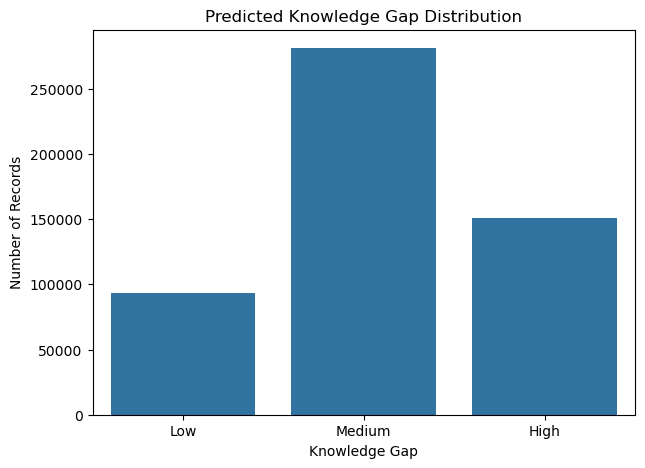

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=student_data,
    x="PredictedKnowledgeGap",
    order=["Low","Medium","High"]
)

plt.title("Predicted Knowledge Gap Distribution")

plt.xlabel("Knowledge Gap")

plt.ylabel("Number of Records")

plt.show()

In [ ]:
weak_students = student_data[
    student_data["PredictedKnowledgeGap"] == "High"
].copy()

print("Students needing recommendations :", weak_students.shape)

weak_students.head()

Students needing recommendations : (150656, 29)


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,school_id,hint_count,hint_total,overlap_time,template_id,first_action,opportunity,KnowledgeGap,WeakSkill,PredictedKnowledgeGap
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,73,0,3,42000,30799,0,1,Medium,NaN,High
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,73,3,4,124564,30060,0,3,Medium,NaN,High
20,33392838,277618,70729,33140,51425,1,0,2,27857,tutor,...,73,3,3,39933,30799,0,3,High,Box and Whisker,High
23,20421232,220674,70730,33178,51463,1,0,2,154880,tutor,...,73,0,4,296134,30060,0,1,High,Box and Whisker,High
24,20421644,220674,70730,33162,51447,1,0,4,53687,tutor,...,73,0,3,124624,30799,0,2,High,Box and Whisker,High


In [ ]:
resource_data = pd.DataFrame({

    "skill_name":[

        "Circle Graph",
        "Median",
        "Equivalent Fractions",
        "Finding Percents",
        "Percent Of",
        "Proportion",
        "Box and Whisker",
        "Rotations",
        "Reflection",
        "Reading a Ruler or Scale",
        "Formula to Solve Quadratic Equation",
        "Solving Systems of Linear Equations",
        "Multiplication Whole Numbers",
        "Computation with Real Numbers",
        "Unknown Skill"

    ],

    "Video":[

        "https://www.youtube.com/results?search_query=Circle+Graph+Khan+Academy",
        "https://www.youtube.com/results?search_query=Median+Khan+Academy",
        "https://www.youtube.com/results?search_query=Equivalent+Fractions+Khan+Academy",
        "https://www.youtube.com/results?search_query=Finding+Percents+Khan+Academy",
        "https://www.youtube.com/results?search_query=Percent+Of+Khan+Academy",
        "https://www.youtube.com/results?search_query=Proportion+Khan+Academy",
        "https://www.youtube.com/results?search_query=Box+and+Whisker+Plot+Khan+Academy",
        "https://www.youtube.com/results?search_query=Rotations+Math",
        "https://www.youtube.com/results?search_query=Reflection+Geometry",
        "https://www.youtube.com/results?search_query=Reading+a+Ruler",
        "https://www.youtube.com/results?search_query=Quadratic+Formula",
        "https://www.youtube.com/results?search_query=Systems+of+Linear+Equations",
        "https://www.youtube.com/results?search_query=Whole+Number+Multiplication",
        "https://www.youtube.com/results?search_query=Real+Numbers",
        "General Mathematics Revision"

    ],

    "Notes":[

        "Circle Graph Notes",
        "Median Notes",
        "Equivalent Fractions Notes",
        "Finding Percents Notes",
        "Percent Of Notes",
        "Proportion Notes",
        "Box and Whisker Notes",
        "Rotations Notes",
        "Reflection Notes",
        "Reading a Ruler Notes",
        "Quadratic Formula Notes",
        "Systems of Linear Equations Notes",
        "Multiplication Notes",
        "Real Numbers Notes",
        "General Mathematics Notes"

    ],

    "Practice":[

        "Circle Graph Worksheet",
        "Median Worksheet",
        "Equivalent Fractions Worksheet",
        "Finding Percents Worksheet",
        "Percent Of Worksheet",
        "Proportion Worksheet",
        "Box and Whisker Worksheet",
        "Rotations Worksheet",
        "Reflection Worksheet",
        "Measurement Worksheet",
        "Quadratic Formula Worksheet",
        "Linear Equations Worksheet",
        "Multiplication Worksheet",
        "Real Numbers Worksheet",
        "General Practice"

    ]

})

resource_data.head()

,skill_name,Video,Notes,Practice
0,Circle Graph,https://www.youtube.com/results?search_query=C...,Circle Graph Notes,Circle Graph Worksheet
1,Median,https://www.youtube.com/results?search_query=M...,Median Notes,Median Worksheet
2,Equivalent Fractions,https://www.youtube.com/results?search_query=E...,Equivalent Fractions Notes,Equivalent Fractions Worksheet
3,Finding Percents,https://www.youtube.com/results?search_query=F...,Finding Percents Notes,Finding Percents Worksheet
4,Percent Of,https://www.youtube.com/results?search_query=P...,Percent Of Notes,Percent Of Worksheet


In [ ]:
recommendation_data = weak_students.merge(
    resource_data,
    on="skill_name",
    how="left"
)

print(recommendation_data.shape)

recommendation_data.head()

(150656, 32)


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,overlap_time,template_id,first_action,opportunity,KnowledgeGap,WeakSkill,PredictedKnowledgeGap,Video,Notes,Practice
0,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,42000,30799,0,1,Medium,NaN,High,https://www.youtube.com/results?search_query=B...,Box and Whisker Notes,Box and Whisker Worksheet
1,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,124564,30060,0,3,Medium,NaN,High,https://www.youtube.com/results?search_query=B...,Box and Whisker Notes,Box and Whisker Worksheet
2,33392838,277618,70729,33140,51425,1,0,2,27857,tutor,...,39933,30799,0,3,High,Box and Whisker,High,https://www.youtube.com/results?search_query=B...,Box and Whisker Notes,Box and Whisker Worksheet
3,20421232,220674,70730,33178,51463,1,0,2,154880,tutor,...,296134,30060,0,1,High,Box and Whisker,High,https://www.youtube.com/results?search_query=B...,Box and Whisker Notes,Box and Whisker Worksheet
4,20421644,220674,70730,33162,51447,1,0,4,53687,tutor,...,124624,30799,0,2,High,Box and Whisker,High,https://www.youtube.com/results?search_query=B...,Box and Whisker Notes,Box and Whisker Worksheet


In [ ]:
recommendation_data["Video"] = recommendation_data["Video"].fillna(
    "General Mathematics Revision"
)

recommendation_data["Notes"] = recommendation_data["Notes"].fillna(
    "General Mathematics Notes"
)

recommendation_data["Practice"] = recommendation_data["Practice"].fillna(
    "General Practice Questions"
)

In [ ]:
def recommend_resources(student_id):

    student = recommendation_data[
        recommendation_data["user_id"] == student_id
    ]

    student = student.sort_values(
        by="hint_count",
        ascending=False
    )

    return student[
        [
            "user_id",
            "skill_name",
            "PredictedKnowledgeGap",
            "Video",
            "Notes",
            "Practice"
        ]
    ]

In [ ]:
recommend_resources(14)

,user_id,skill_name,PredictedKnowledgeGap,Video,Notes,Practice
117404,14,Unknown Skill,High,General Mathematics Revision,General Mathematics Notes,General Practice
736,14,Circle Graph,High,https://www.youtube.com/results?search_query=C...,Circle Graph Notes,Circle Graph Worksheet
22176,14,Unknown Skill,High,General Mathematics Revision,General Mathematics Notes,General Practice
52050,14,Finding Percents,High,https://www.youtube.com/results?search_query=F...,Finding Percents Notes,Finding Percents Worksheet
117401,14,Unknown Skill,High,General Mathematics Revision,General Mathematics Notes,General Practice
117402,14,Unknown Skill,High,General Mathematics Revision,General Mathematics Notes,General Practice
7721,14,Median,High,https://www.youtube.com/results?search_query=M...,Median Notes,Median Worksheet
34198,14,Equivalent Fractions,High,https://www.youtube.com/results?search_query=E...,Equivalent Fractions Notes,Equivalent Fractions Worksheet
7719,14,Median,High,https://www.youtube.com/results?search_query=M...,Median Notes,Median Worksheet
731,14,Circle Graph,High,https://www.youtube.com/results?search_query=C...,Circle Graph Notes,Circle Graph Worksheet


In [ ]:
top_students = recommendation_data.groupby(
    "user_id"
).size().sort_values(
    ascending=False
).head(10)

top_students

user_id
92246    2960
92250    1806
92249    1352
92251    1139
78978     848
79032     845
96274     804
78588     772
79029     769
79021     737
dtype: int64

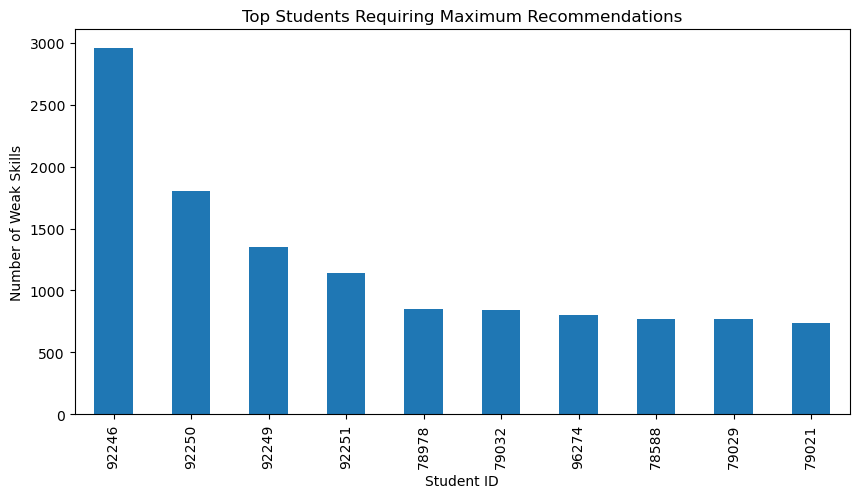

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

top_students.plot(kind="bar")

plt.title("Top Students Requiring Maximum Recommendations")

plt.xlabel("Student ID")

plt.ylabel("Number of Weak Skills")

plt.show()

In [ ]:
# Sort recommendations by hint count (higher hints = higher priority)
recommendation_data = recommendation_data.sort_values(
    by=["user_id", "hint_count"],
    ascending=[True, False]
)

# Remove Unknown Skill recommendations
recommendation_data = recommendation_data[
    recommendation_data["skill_name"] != "Unknown Skill"
]

# Remove duplicate skills for each student
final_recommendations = recommendation_data.drop_duplicates(
    subset=["user_id", "skill_name"]
)

# Keep only Top 5 recommendations for each student
final_recommendations = (
    final_recommendations
    .groupby("user_id")
    .head(5)
)

print("Final Recommendation Dataset Shape:")
print(final_recommendations.shape)

# Save the final recommendations
import os

os.makedirs("../data/final", exist_ok=True)

final_recommendations.to_csv(
    "../data/final/student_recommendations.csv",
    index=False
)

print("Recommendation Dataset Saved Successfully!")

Final Recommendation Dataset Shape:
(10423, 32)
Recommendation Dataset Saved Successfully!


In [ ]:
print("=" * 60)
print("HYBRID RECOMMENDATION SYSTEM COMPLETED")
print("=" * 60)

total_students = student_data["user_id"].nunique()

students_requiring_help = final_recommendations["user_id"].nunique()

total_recommendations = len(final_recommendations)

print(f"Total Students in Dataset           : {total_students}")
print(f"Students Requiring Help             : {students_requiring_help}")
print(f"Total Personalized Recommendations  : {total_recommendations}")

print("=" * 60)

HYBRID RECOMMENDATION SYSTEM COMPLETED
Total Students in Dataset           : 4217
Students Requiring Help             : 3740
Total Personalized Recommendations  : 11360


In [ ]:
student_id = int(input("Enter Student ID: "))

print("=" * 70)
print(f"PERSONALIZED LEARNING REPORT FOR STUDENT {student_id}")
print("=" * 70)

display(
    final_recommendations[
        final_recommendations["user_id"] == student_id
    ][
        [
            "skill_name",
            "PredictedKnowledgeGap",
            "Video",
            "Notes",
            "Practice"
        ]
    ]
)

print("=" * 70)
print("End of Report")

PERSONALIZED LEARNING REPORT FOR STUDENT 21825


,skill_name,PredictedKnowledgeGap,Video,Notes,Practice
5133,Table,High,General Mathematics Revision,General Mathematics Notes,General Practice Questions
7722,Median,High,https://www.youtube.com/results?search_query=M...,Median Notes,Median Worksheet


End of Report
